## Import datasets and create data format yolo

In [5]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import shutil
import os
import json
ds = load_dataset("keremberke/license-plate-object-detection", "full")

In [6]:
# import os
# import json
# from PIL import Image

# def save_images_and_info(dataset, split_name, save_dir="../license-plate-dataset"):
#     """
#     Lưu ảnh và metadata của từng sample từ dataset vào các thư mục:
#       - save_dir/split_name/image: lưu ảnh
#       - save_dir/split_name/info: lưu metadata (JSON)
#     """
#     image_dir = os.path.join(save_dir, split_name, "image")
#     info_dir = os.path.join(save_dir, split_name, "info")
#     os.makedirs(image_dir, exist_ok=True)
#     os.makedirs(info_dir, exist_ok=True)

#     for sample in dataset:
#         image_id = sample["image_id"]
#         image = sample["image"]  

#         # Lưu ảnh
#         image_path = os.path.join(image_dir, f"{image_id}.png")
#         image.save(image_path)

#         info = {k: sample[k] for k in sample if k != "image"}

#         # Lưu metadata vào file JSON
#         info_path = os.path.join(info_dir, f"{image_id}.json")
#         with open(info_path, "w") as f:
#             json.dump(info, f, indent=4)

#         print(f"Lưu ảnh: {image_path} và metadata: {info_path}")

save_dir = "../license-plate-dataset"
# save_images_and_info(ds["train"], "train", save_dir=save_dir)
# save_images_and_info(ds["validation"], "validation", save_dir=save_dir)
# save_images_and_info(ds["test"], "test", save_dir=save_dir)

In [7]:
def convert_to_yolo_format(data_list):
    """
    Chuyển đổi dữ liệu bounding box theo định dạng:
      (img_path, [w_img, h_img], [ [x, y, w, h], ... ])
    sang định dạng YOLO:
      (img_path, [ "class_id x_center y_center w h", ... ])
    
    Mọi giá trị tọa độ và kích thước sẽ được chuẩn hóa theo kích thước ảnh.
    Giả sử chỉ có 1 class (class_id = 0).
    """
    yolo_data = []
    for img_path, img_size, bboxs in data_list:
        data_img = []
        w_img, h_img = img_size
        for bbox in bboxs:
            x, y, w, h = bbox
            # Tính tâm bounding box
            x_center = x + w / 2
            y_center = y + h / 2

            # Chuẩn hóa theo kích thước ảnh
            x_center /= w_img
            y_center /= h_img
            w /= w_img
            h /= h_img

            # Với 1 class, gán class_id = 0
            label = 0
            yolo_label = f"{label} {x_center} {y_center} {w} {h}"
            data_img.append(yolo_label)
        yolo_data.append((img_path, data_img))
    return yolo_data


# Ví dụ sử dụng:
data_list = [
    ('../license-plate-dataset/train/image/0.png',
     [472, 303], [[185.0, 231.0, 107.0, 37.0]]),
    ('../license-plate-dataset/train/image/1.png',
     [472, 303], [[172.0, 95.0, 96.0, 83.0]])
]

yolo_data = convert_to_yolo_format(data_list)
print(yolo_data)

[('../license-plate-dataset/train/image/0.png', ['0 0.5052966101694916 0.8234323432343235 0.2266949152542373 0.12211221122112212']), ('../license-plate-dataset/train/image/1.png', ['0 0.4661016949152542 0.4504950495049505 0.2033898305084746 0.2739273927392739'])]


In [8]:
def get_img_paths_info(folder_dir=''):
    image_folder = os.path.join(folder_dir, 'image')
    info_folder = os.path.join(folder_dir, 'info')
    json_files = os.listdir(info_folder)[:10]
    image_paths = os.listdir(image_folder)[:10]
    data_list = []
    for i, json_file in enumerate(json_files):
        json_path = os.path.join(info_folder, json_file)
        image_path = os.path.join(image_folder, image_paths[i])
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            img_size = [data['width'], data['height']]
            bboxs = data['objects']['bbox']
        data_list.append((image_path, img_size, bboxs))
    return data_list


# Ví dụ sử dụng:
save_dir = "../license-plate-dataset"
result = get_img_paths_info(os.path.join(save_dir, "train"))
print("Kết quả:", result)

Kết quả: [('../license-plate-dataset\\train\\image\\0.png', [472, 303], [[185.0, 231.0, 107.0, 37.0]]), ('../license-plate-dataset\\train\\image\\1.png', [472, 303], [[172.0, 95.0, 96.0, 83.0]]), ('../license-plate-dataset\\train\\image\\10.png', [472, 303], [[239.0, 139.0, 98.0, 30.0]]), ('../license-plate-dataset\\train\\image\\100.png', [472, 303], [[192.0, 34.0, 86.0, 63.0]]), ('../license-plate-dataset\\train\\image\\1000.png', [472, 303], [[156.0, 115.0, 99.0, 84.0]]), ('../license-plate-dataset\\train\\image\\1001.png', [472, 303], [[317.0, 179.0, 80.0, 53.0]]), ('../license-plate-dataset\\train\\image\\1002.png', [472, 303], [[154.0, 120.0, 92.0, 82.0]]), ('../license-plate-dataset\\train\\image\\1003.png', [472, 303], [[196.0, 101.0, 103.0, 81.0]]), ('../license-plate-dataset\\train\\image\\1004.png', [472, 303], [[215.0, 240.0, 99.0, 25.0]]), ('../license-plate-dataset\\train\\image\\1005.png', [450, 290], [[144.0, 210.0, 65.0, 49.0]])]


In [9]:

def save_yolo_data_dir(data, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(save_dir, "labels"), exist_ok=True)
    
    yolo_data = convert_to_yolo_format(data[:10])
    for sample_data in yolo_data:
        print(sample_data)
        image_path = sample_data[0]
        yolo_labels = sample_data[1]
        # Sao chép tệp ảnh từ thư mục gốc sang thư mục yolo
        shutil.copy(image_path, os.path.join(save_dir, "images"))

        # lấy tên file ảnh và tên file label
        image_name = os.path.basename(image_path)
        label_name = os.path.splitext(image_name)[0]
        with open(os.path.join(save_dir, "labels", f"{label_name}.txt"), "w") as f:
            for yolo_label in yolo_labels:
                f.write(yolo_label + "\n")


save_dir = '../datasets/yolo_license_plate'
os.makedirs(save_dir, exist_ok=True)
save_train_dir = os.path.join(save_dir, 'train')
save_val_dir = os.path.join(save_dir, 'val')
save_test_dir = os.path.join(save_dir, 'test')

train_data = get_img_paths_info('../license-plate-dataset/train')
val_data = get_img_paths_info('../license-plate-dataset/validation')
test_data = get_img_paths_info('../license-plate-dataset/test')
save_yolo_data_dir(train_data, save_train_dir)
save_yolo_data_dir(val_data, save_val_dir)
save_yolo_data_dir(test_data, save_test_dir)

('../license-plate-dataset/train\\image\\0.png', ['0 0.5052966101694916 0.8234323432343235 0.2266949152542373 0.12211221122112212'])
('../license-plate-dataset/train\\image\\1.png', ['0 0.4661016949152542 0.4504950495049505 0.2033898305084746 0.2739273927392739'])
('../license-plate-dataset/train\\image\\10.png', ['0 0.6101694915254238 0.5082508250825083 0.2076271186440678 0.09900990099009901'])
('../license-plate-dataset/train\\image\\100.png', ['0 0.4978813559322034 0.21617161716171618 0.18220338983050846 0.2079207920792079'])
('../license-plate-dataset/train\\image\\1000.png', ['0 0.4353813559322034 0.5181518151815182 0.2097457627118644 0.27722772277227725'])
('../license-plate-dataset/train\\image\\1001.png', ['0 0.7563559322033898 0.6782178217821783 0.1694915254237288 0.17491749174917492'])
('../license-plate-dataset/train\\image\\1002.png', ['0 0.423728813559322 0.5313531353135313 0.19491525423728814 0.2706270627062706'])
('../license-plate-dataset/train\\image\\1003.png', ['0 0.

In [10]:
import os
import yaml

# Đường dẫn gốc đến dataset (sửa lại cho phù hợp với máy bạn)
dataset_root = r"D:\Asus\AIO\Project\Scene-Text-Recognition\datasets\yolo_license_plate"

class_labels = ["number"]

# Tạo nội dung file data.yaml với các đường dẫn tương đối so với 'path'
data_yaml = {
    "path": dataset_root,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 1,
    "names": class_labels
}

# Đường dẫn để lưu file data.yaml
yolo_yaml_path = os.path.join(dataset_root, "data.yaml")
with open(yolo_yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("File data.yaml đã được tạo tại:", yolo_yaml_path)

File data.yaml đã được tạo tại: D:\Asus\AIO\Project\Scene-Text-Recognition\datasets\yolo_license_plate\data.yaml


In [11]:
! pip install -U ultralytics

In [16]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11m.pt")

# Train model
results = model.train(
    data=yolo_yaml_path,
    epochs=5,
    imgsz=640,
    cache=True,
    patience=20,
    plots=True,
)

Ultralytics 8.3.96  Python-3.10.15 torch-1.12.1+cpu CPU (AMD Ryzen 7 6800H with Radeon Graphics)
WARNING  Upgrade to torch>=2.0.0 for deterministic training.
engine\trainer: task=detect, mode=train, model=yolo11m.pt, data=D:\Asus\AIO\Project\Scene-Text-Recognition\datasets\yolo_license_plate\data.yaml, epochs=5, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None

train: Scanning D:\Asus\AIO\Project\Scene-Text-Recognition\datasets\yolo_license_plate\train\labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]

WARNING  cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.



train: Caching images (0.0GB RAM): 100%|██████████| 10/10 [00:00<00:00, 320.75it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

  0%|          | 0/1 [00:00<?, ?it/s]d:\Asus\Ungdung\Miniconda\workspace\envs\AIOEx\lib\site-packages\torch\amp\autocast_mode.py:198: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')
        5/5         0G      1.114       2.49      1.156         20        640: 100%|██████████| 1/1 [00:14<00:00, 14.84s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<00:00,  4.02s/it]

                   all         10         10      0.966        0.2      0.286      0.158



5 epochs completed in 0.038 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 40.5MB
Optimizer stripped from runs\detect\train\weights\best.pt, 40.5MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.96  Python-3.10.15 torch-1.12.1+cpu CPU (AMD Ryzen 7 6800H with Radeon Graphics)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:03<00:00,  3.42s/it]


                   all         10         10      0.966        0.2      0.286      0.158
Speed: 1.0ms preprocess, 327.5ms inference, 0.0ms loss, 10.2ms postprocess per image
Results saved to runs\detect\train


In [13]:
print(dir(results))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'ap_class_index', 'box', 'class_result', 'confusion_matrix', 'curves', 'curves_results', 'fitness', 'keys', 'maps', 'mean_results', 'names', 'plot', 'process', 'results_dict', 'save_dir', 'speed', 'task']


In [15]:
print("Precision:", results.box.p.tolist())
print("Recall:", results.box.r.tolist())
print("F1 score:", results.box.f1.tolist())
print("AP at IoU=0.5:", results.box.ap50.tolist())
print("AP at IoU=0.5:0.95:", results.box.ap.tolist())
print("mAP:", results.box.maps.tolist())
print("Fitness:", results.box.fitness)

Precision: [0.478378509668144]
Recall: [0.3]
F1 score: [0.3687500390051342]
AP at IoU=0.5: [0.33150306143125213]
AP at IoU=0.5:0.95: [0.21533905100676667]
mAP: [0.21533905100676667]
Fitness: <bound method Metric.fitness of ultralytics.utils.metrics.Metric object with attributes:

all_ap: array([[     0.3315,      0.3315,     0.33094,     0.31757,     0.31757,     0.31622,       0.169,    0.019657,    0.019435,           0]])
ap: array([    0.21534])
ap50: array([     0.3315])
ap_class_index: array([0])
curves: []
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.03

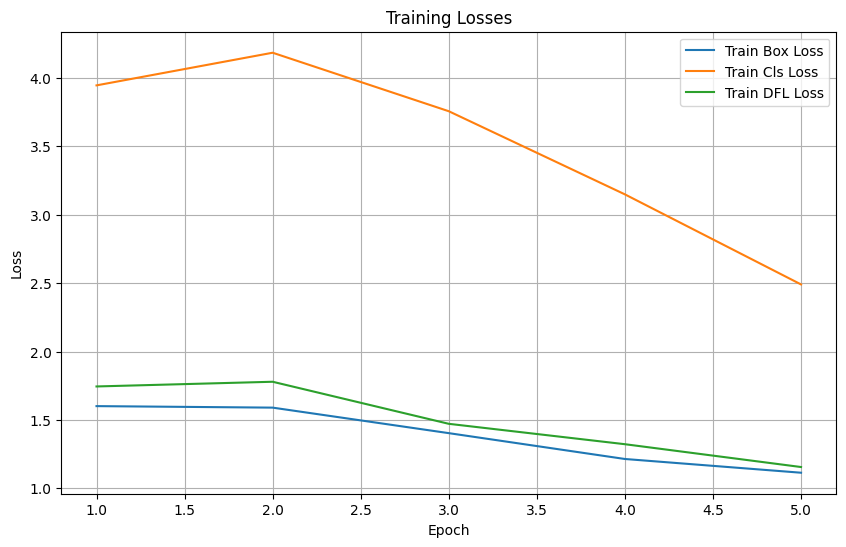

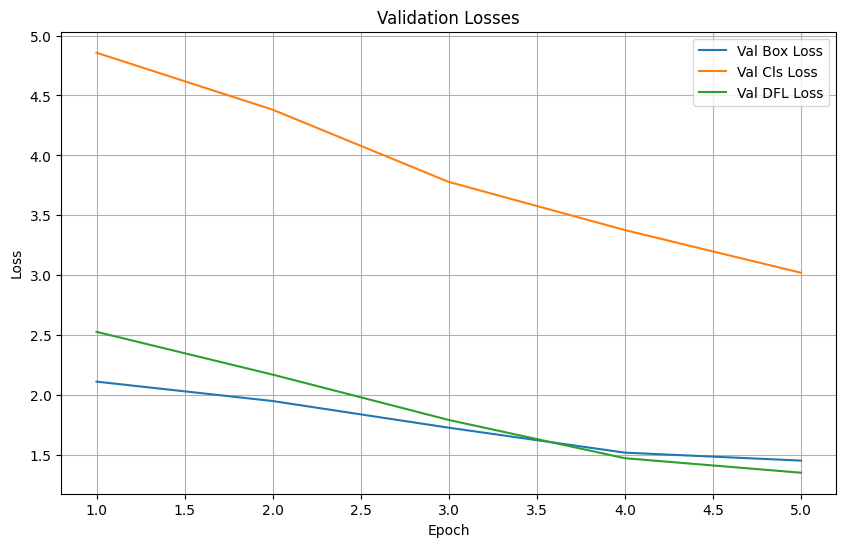

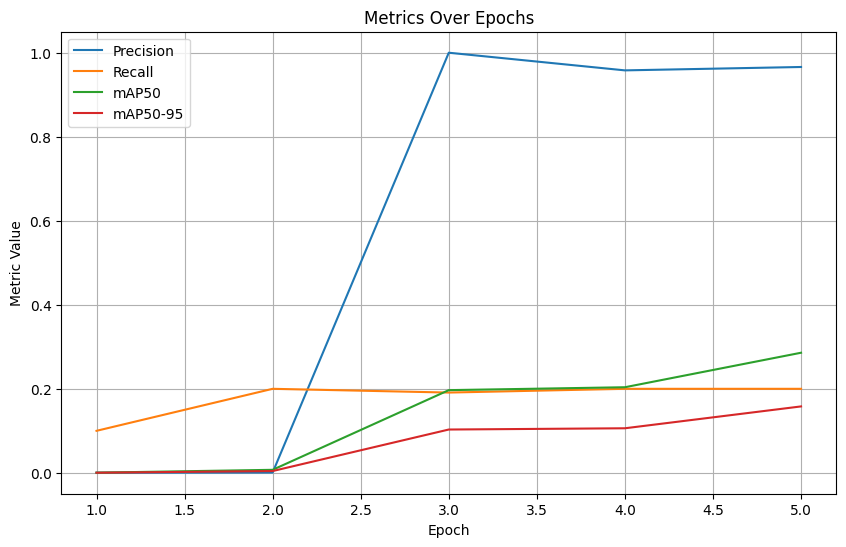

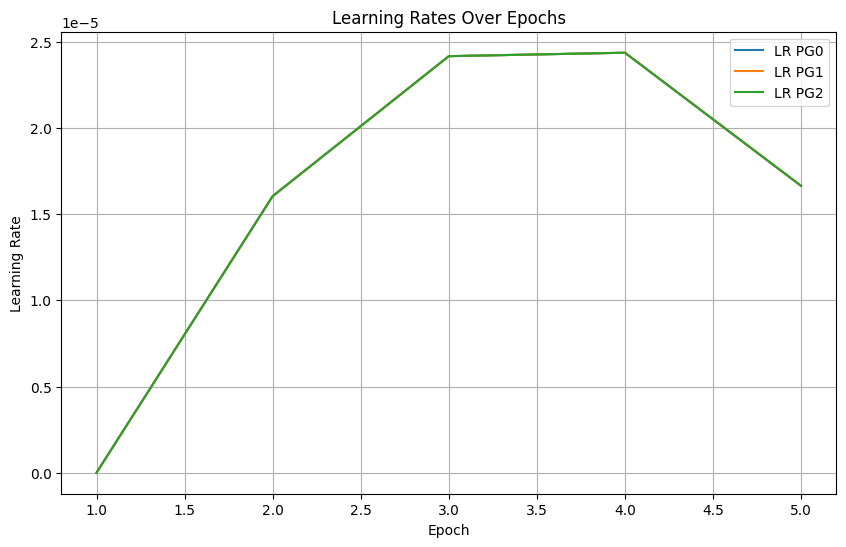

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

def plot_training_metrics(csv_path):
    # Đọc file CSV
    df = pd.read_csv(csv_path)

    # Lấy số epoch
    epochs = df['epoch']

    # Plot Training Losses
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, df['train/box_loss'], label='Train Box Loss')
    plt.plot(epochs, df['train/cls_loss'], label='Train Cls Loss')
    plt.plot(epochs, df['train/dfl_loss'], label='Train DFL Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Validation Losses
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, df['val/box_loss'], label='Val Box Loss')
    plt.plot(epochs, df['val/cls_loss'], label='Val Cls Loss')
    plt.plot(epochs, df['val/dfl_loss'], label='Val DFL Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Losses')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Metrics: Precision, Recall, mAP50, mAP50-95
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, df['metrics/precision(B)'], label='Precision')
    plt.plot(epochs, df['metrics/recall(B)'], label='Recall')
    plt.plot(epochs, df['metrics/mAP50(B)'], label='mAP50')
    plt.plot(epochs, df['metrics/mAP50-95(B)'], label='mAP50-95')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('Metrics Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Learning Rates nếu cần
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, df['lr/pg0'], label='LR PG0')
    plt.plot(epochs, df['lr/pg1'], label='LR PG1')
    plt.plot(epochs, df['lr/pg2'], label='LR PG2')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rates Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Ví dụ sử dụng:
plot_training_metrics("./runs/detect/train/results.csv")